# Pairwise Consistency Models & Variational Dynamics (VarCM)

---

## 1. Pairwise Consistency Model (CM)

### 1.1 Motivation

Classical consistency models (Song et al., 2023) are trained to map any noisy sample $\mathbf{x}_\sigma = \mathbf{x} + \sigma \mathbf{z}$ directly to the clean signal $\mathbf{x}_0$. This yields an efficient, one-shot approximation of the entire reverse diffusion trajectory. We generalise this principle to **pairwise consistency** between two arbitrary diffusion levels $\sigma, \sigma'$, allowing interpolation or extrapolation across the continuous diffusion-time axis.

### 1.2 Definition

The pairwise consistency operator $g_\phi$ learns the transport from $\sigma$ to $\sigma'$ ($\sigma > \sigma'$):

$$
g_\phi(\mathbf{x}_\sigma,\sigma,\sigma') =
\alpha(\sigma,\sigma')\,\mathbf{x}_\sigma +
\beta(\sigma,\sigma')\,G_\phi(\mathbf{x}_\sigma,\sigma,\sigma')
$$

where $G_\phi$ is a UNet estimating the integrated reverse drift:

$$
G_\phi(\mathbf{x}_\sigma,\sigma,\sigma') \approx \int_{\sigma'}^{\sigma} D(\mathbf{x}_s,s)\,ds
$$

The standard one-shot CM $f_\theta(\mathbf{x}_\sigma,\sigma) \approx \mathbf{x}_0$ is recovered at $\sigma'=\sigma_{\min}$.

### 1.3 Training loss

$$
\mathcal{L}_{\text{CM}} =
\mathbb{E}_{\mathbf{x}_0,\mathbf{z},\sigma,\sigma',\sigma''}\!
\left[\left\| g_\phi(\mathbf{x}_\sigma,\sigma,\sigma'') - g_\phi(\mathbf{x}_{\sigma'},\sigma',\sigma'') \right\|^2\right]
$$

where the teacher/student trick stabilises the stop-gradient target.

### 1.4 Sampling: probability-flow ODE vs. reverse SDE

| Mode | Update rule |
|------|-------------|
| **ODE** (deterministic) | $\mathbf{x}_{t'} = \alpha(t,t')\mathbf{x}_t + \beta(t,t')\,\boldsymbol{\mu}_\phi(\mathbf{x}_t,t,t')$ |
| **SDE** (stochastic)    | $\mathbf{x}_{t'} = \alpha(t,t')\mathbf{x}_t + \beta(t,t')\,\boldsymbol{\mu}_\phi(\mathbf{x}_t,t,t') + \mathbf{L}_\phi(\mathbf{x}_t,t,t')\,\boldsymbol{\varepsilon}$ |

The ODE converges toward the posterior MAP, while the SDE preserves trajectory dispersion and approximates posterior sampling.

---

## 2. Pairwise Self-Consistency in Variational Dynamics (VarCM)

In classical CM, pairs $(\mathbf{x}_\sigma, \mathbf{x}_{\sigma'})$ are available analytically from the prescribed forward diffusion. In variational data assimilation, **no explicit forward SDE** governs the state dynamics. Instead, the dynamics are defined by the gradient flow of a variational cost:

$$
J(\mathbf{x}) = \underbrace{\|\mathcal{H}\mathbf{x} - \mathbf{y}\|^2}_{\text{observation}} + \underbrace{\|\mathbf{x} - \Phi(\mathbf{x})\|^2}_{\text{prior (learned)}},
\qquad
\frac{d\mathbf{x}_t}{dt} = -\nabla_\mathbf{x} J(\mathbf{x}_t)
$$

We use a **teacher-free, on-the-fly EMA** formulation to train without a known forward process.

### 2.1 Network preconditioning

Following the EDM (Karras et al.) preconditioning with the **linear interpolant** schedule $\alpha(t)=t$, $\beta(t)=1-t$:

$$
c_\text{in}(t) = \frac{1}{\sqrt{\sigma_\text{data}^2(1-t)^2 + \sigma_\text{noise}^2\,t^2}}, \quad
c_\text{skip}(t,t') = \frac{\alpha(t')}{\alpha(t)}, \quad
c_\text{out}(t,t') = \beta(t') - c_\text{skip}\,\beta(t)
$$

The transport operator is:

$$
g_\phi(\mathbf{x}_t, \nabla J_\Phi(\mathbf{x}_t), t, t') =
c_\text{skip}(t,t')\,\mathbf{x}_t + c_\text{out}(t,t')\,F_\theta\!\left(c_\text{in}(t)\,\mathbf{x}_t,\;\nabla J_\Phi(\mathbf{x}_t),\;t,\;t'\right)
$$

Boundary conditions: $g_\phi(\mathbf{x}_t, \cdot, t, t) = \mathbf{x}_t$ (identity), $g_\phi(\mathbf{x}_t, \cdot, t, 0) = F_\theta(\cdot)$ (pure prediction at $\mathbf{x}_0$-scale).

### 2.2 Stabilised three-term training loss

**Key design choice: all predictions are evaluated at $t''=0$.**

At $t'=0$: $c_\text{skip}=0$, $c_\text{out}=1$, so $g_\phi(\cdot, t, 0) = F_\theta(\cdot)$ outputs directly at $\mathbf{x}_0$-scale.
Fixing $t''=0$ across all three terms eliminates the *scale contradiction* that causes loss explosion when $t''\neq 0$ (where student and teacher outputs live at different noise scales).

**Time sampling:** draw $t > t'$ from the interior of the Karras schedule (both $> 0$ and $< T$).

**Initial state:** $\mathbf{x}_T = \sigma_\text{noise}\,\mathbf{z}$, $\mathbf{z}\sim\mathcal{N}(0,\mathbf{I})$ — pure noise, no data leakage.

$$
\boxed{
\mathcal{L}_{\text{VarCM}} =
\underbrace{\left\|g_s\!\bigl(g_t(\mathbf{x}_T,T,t),\,t,\,0\bigr)
- \mathrm{sg}\!\left[g_t\!\bigl(g_t(\mathbf{x}_T,T,t'),\,t',\,0\bigr)\right]\right\|^2}_{\text{Term 1: }L_\text{pair}}
+\,\lambda_\text{long}\underbrace{\left\|g_s\!\bigl(g_t(\mathbf{x}_T,T,t),\,t,\,0\bigr) - \mathbf{x}_0\right\|^2}_{\text{Term 2: }L_\text{long}}
+\,\lambda_\text{short}\underbrace{\left\|g_s\!\bigl(\mathrm{sg}[g_s(\mathbf{x}_t,t,t')],\,t',\,0\bigr) - \mathbf{x}_0\right\|^2}_{\text{Term 3: }L_\text{short}}
}
$$

with $t > t'$ and $\mathrm{sg}[\cdot]$ = stop-gradient / teacher EMA branch.
$\mathbf{x}_t = \alpha(t)\,\mathbf{x}_T + \beta(t)\,\mathbf{x}_0$ is the linear interpolant used as starting point for Term 3.

**Implementation notes:**
- $L_\text{pair}$ and $L_\text{long}$ **share the same student forward pass** $g_s(g_t(\mathbf{x}_T,T,t),\,t,\,0)$, so only one student call is needed for both.
- The teacher intermediates $g_t(\mathbf{x}_T,T,t)$, $g_t(\mathbf{x}_T,T,t')$, and $g_t(g_t(\mathbf{x}_T,T,t'),t',0)$ are all computed under `torch.no_grad()`.
- In Term 3, the intermediate $x_\text{mid}=g_s(\mathbf{x}_t,t,t')$ is explicitly detached so gradient flows only through the final step.

**Role of each term:**
- **$L_\text{pair}$** — enforces semigroup property: two-step reconstructions of $\mathbf{x}_0$ via $T\!\to\!t\!\to\!0$ and $T\!\to\!t'\!\to\!0$ must agree (both are $\mathbf{x}_0$-scale → no scale mismatch).
- **$L_\text{long}$** — long-chain anchor: the full trajectory $\mathbf{x}_T\!\to\!t\!\to\!0$ must recover $\mathbf{x}_0$ (compensates for absence of forward process).
- **$L_\text{short}$** — short-chain anchor: partial trajectories $\mathbf{x}_t\!\to\!t'\!\to\!0$ must also recover $\mathbf{x}_0$; encourages all intermediate states to lie on the data manifold.

Terms 2 & 3 together replace the explicit forward SDE and guarantee that the learned operator connects to the data distribution.

### 2.3 Stochastic self-consistency training

The network now predicts Gaussian parameters $(\boldsymbol{\mu}_\phi, \boldsymbol{\Sigma}_\phi)$ and the transition becomes:

$$
\mathbf{x}_{t'} = \boldsymbol{\mu}_\phi(\mathbf{x}_t, t, t') + \mathbf{L}_\phi\,\boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon}\sim\mathcal{N}(0,\mathbf{I})
$$

The complete stochastic loss:

$$
\mathcal{L}_{\text{SDE}} = \mathcal{L}_{\text{comp}} + \lambda_{\text{anc}}\,\mathcal{L}_{\text{anc}}
$$

- **$\mathcal{L}_\text{comp}$**: pairwise consistency on *deterministic means* (stabilises drift).
- **$\mathcal{L}_\text{anc}$**: isotropic Gaussian NLL anchoring to $\mathbf{x}_0$:

$$
\mathcal{L}_{\text{anc}} =
\mathbb{E}_{\mathbf{x}_T,t}\!\left[\frac{\|\mathbf{x}_0 - \boldsymbol{\mu}_{T\to t\to 0}\|^2}{2\sigma^2_{T,t,0}} + \frac{d}{2}\log\sigma^2_{T,t,0}\right]
+ \mathbb{E}_{t,t'}\!\left[\frac{\|\mathbf{x}_0 - \boldsymbol{\mu}_{t\to t'\to 0}\|^2}{2\sigma^2_{t,t',0}} + \frac{d}{2}\log\sigma^2_{t,t',0}\right]
$$

### 2.4 Covariance parameterizations

| Type | Form | Loss |
|------|------|------|
| **Diagonal** | $\boldsymbol{\Sigma} = \mathrm{diag}(\sigma_i^2)$ | Weighted elementwise MSE + $\sum_i\log\sigma_i^2$ |
| **Isotropic** *(implemented)* | $\boldsymbol{\Sigma} = \sigma^2(t,t')\,\mathbf{I}$ | $\|\mathbf{x}-\boldsymbol{\mu}\|^2/(2\sigma^2) + (d/2)\log\sigma^2$ |
| **Structured (SPDE)** | $\boldsymbol{\Sigma}^{-1} = \alpha_\phi\,\mathcal{L}_\phi$ | Precision-weighted NLL, $-\frac{1}{2}\log\det(\alpha_\phi\mathcal{L}_\phi)$ |

---


In [1]:
!nvidia-smi

Thu Apr 30 13:39:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   25C    P8             24W /  300W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_VISIBLE_DEVICES=2


In [3]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.consistency_models_VarCM as _cm_var
importlib.reload(_cm_var)

from consistency_models.consistency_models_VarCM import (
    VariationalConsistencySampling,
    model_variational_forward_wrapper,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("[WARNING] properscoring not installed -- CRPS disabled. Install with: pip install properscoring")


## Implementation

### DataModule -- SPDE Diffusion Dataset

In [4]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes -- input (y): (5, 128, 128), tgt (x): (5, 128, 128)
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size (C) = 5
TrainingItem shapes -- input (y): (5, 128, 128), tgt (x): (5, 128, 128)


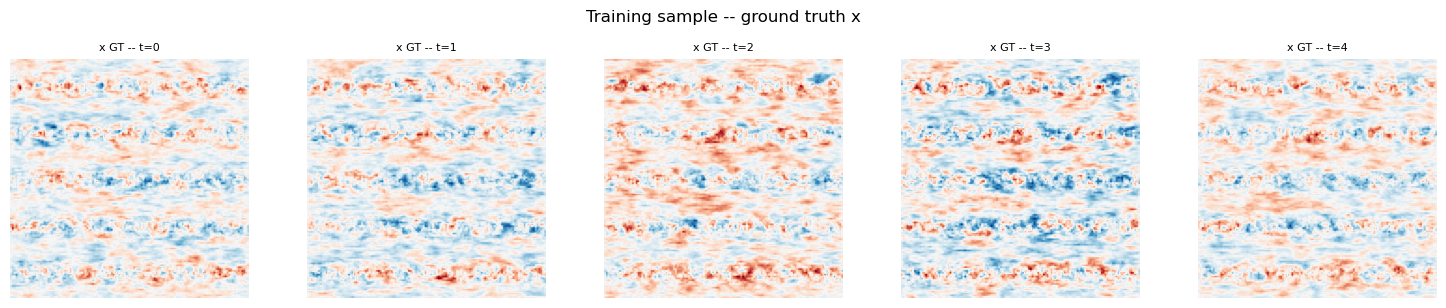

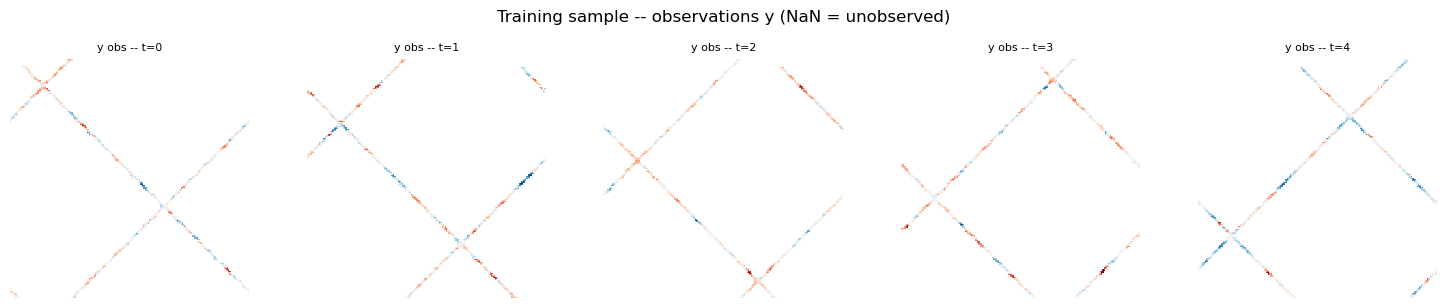

In [5]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes -- input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- observations y (NaN = unobserved)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, `TimeEmbedding` (for **t** and **t'** separately), `_pad_to_multiple`, `_unpad`.

In [6]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier time embedding for a scalar t in [0, 1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100x100 -> 104x104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### Variational UNet

Differences vs the classic PWCM UNet:
- **`input_projection`**: takes `c_in(t) * x` -- **C** channels (not 3C)
- **`grad_j_projection`**: takes `grad_J` -- **C** channels, added to the output of `input_projection`
- **Two `TimeEmbedding`**: one for `t`, one for `t'`, concatenated -> `2 x time_level_channels`
- No observations y in the forward pass (handled upstream via `model_variational_forward_wrapper`)

In [7]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    stoch: bool = False   # If True: outputs (mu, log_sigma) for stochastic VarCM


class UNet(nn.Module):
    """
    Variational UNet: takes (c_in*x, cond, t, t') as input.

    Two conditioning modes (selected automatically from cond.shape[1]):
      - grad mode : cond = grad_J  (C channels)  -> grad_j_projection (C -> top)
      - obs  mode : cond = cat([y_filled, mask])  (2C channels) -> obs_projection (2C -> top)

    - input_projection  : C  -> top_ch[0]  (for c_in*x)
    - Two TimeEmbedding concatenated -> conditioning 2xTLC

    Stochastic mode (config.stoch=True):
      An additional scalar head (global-avg-pool + MLP) predicts log σ per sample.
      forward() returns (mu: (B,C,H,W), log_sigma: (B,1)) instead of a single Tensor.
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # x projection (always C channels)
        self.input_projection  = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # grad mode: C channels  (grad_J, normalised to unit std)
        self.grad_j_projection = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # obs  mode: 2C channels (y_filled + mask)
        self.obs_projection    = nn.Conv2d(2 * C, top, kernel_size=3, padding="same")

        # One embedding per solver time (t and t')
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(top, C, kernel_size=3, padding="same")

        # Stochastic head: predict scalar log σ from pooled decoder features
        if config.stoch:
            self.log_sigma_head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),   # (B, top, H, W) -> (B, top, 1, 1)
                nn.Flatten(),              # -> (B, top)
                nn.Linear(top, top // 4),
                nn.SiLU(),
                nn.Linear(top // 4, 1),   # -> (B, 1)  scalar log σ
            )

    def forward(self, x: Tensor, cond: Tensor, t: Tensor, t_prime: Tensor
                ) -> Union[Tensor, Tuple[Tensor, Tensor]]:
        """
        x    : (B, C,   H, W)  -- c_in(t) * current state
        cond : (B, C,   H, W)  -- grad_J  (grad mode, C channels)
             | (B, 2C,  H, W)  -- cat([y_filled, mask])  (obs mode, 2C channels)
        t, t_prime : (B,)

        Returns:
          stoch=False : out          (B, C, H, W)
          stoch=True  : (mu, log_σ)  (B,C,H,W),  (B,1)
        """
        x,    px = _pad_to_multiple(x,    multiple=8)
        cond, _  = _pad_to_multiple(cond, multiple=8)

        # Route conditioning to the appropriate projection
        if cond.shape[1] == self.config.channels:
            cond_proj = self.grad_j_projection(cond)
        else:
            cond_proj = self.obs_projection(cond)

        h = self.input_projection(x) + cond_proj

        # Conditioning: t and t' -> concat on channel dim
        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        out = _unpad(out, px)

        if self.config.stoch:
            log_sigma = self.log_sigma_head(h)   # (B, 1)
            return out, log_sigma

        return out

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check -- test both conditioning modes (stoch=False, default)
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C))
summary(
    _unet,
    input_size=(
        (1, C, 100, 100),       # x (c_in * x)
        (1, C, 100, 100),       # cond: grad mode (C channels)
        (1,),                    # t
        (1,),                    # t'
    ),
    col_names=["input_size", "output_size", "num_params"],
    verbose=0,
)
_unet = _unet.cpu()

# Stochastic mode check
_unet_s = UNet(UNetConfig(channels=C, stoch=True))
_x_dummy  = torch.randn(1, C, 100, 100)
_cond_obs = torch.randn(1, 2 * C, 100, 100)
_t_dummy  = torch.rand(1)
with torch.no_grad():
    _mu, _log_sigma = _unet_s(_x_dummy, _cond_obs, _t_dummy, _t_dummy)
print(f"[OK] UNet stoch=True: mu {_mu.shape}  log_sigma {_log_sigma.shape}")
_unet_s = _unet_s.cpu()


[OK] UNet stoch=True: mu torch.Size([1, 5, 100, 100])  log_sigma torch.Size([1, 1])


### Variational Costs

- **`BaseObsCost`**: $J_o(x, y) = \|M(x - y)\|^2$ (NaN mask)
- **`BilinAEPriorCost`**: $J_b(x) = \|x - \Phi(x)\|^2$ with $\Phi$ = bilinear auto-encoder
- **`lambda_reg`**: `nn.Parameter` scalar $\geq 0$ weighting $J_b$ in $J = J_o + \lambda J_b$

In [8]:
class BaseObsCost(nn.Module):
    """
    Quadratic observation cost: J_o(x, y) = ||M*(x - y)||^2 / (2 * sigma_obs^2)
    M = binary mask (1 where y is observed, 0 where y is NaN).
    """
    def __init__(self, sigma_obs: float = 1.0) -> None:
        super().__init__()
        self.sigma_obs = sigma_obs

    def forward(self, x: Tensor, y: Tensor) -> Tensor:
        """Returns a scalar."""
        mask = (~torch.isnan(y)).to(dtype=x.dtype)
        y_c  = torch.nan_to_num(y, nan=0.0)
        diff = mask * (x - y_c)
        return (diff ** 2).sum() / (2.0 * self.sigma_obs ** 2)


class BilinAEPriorCost(nn.Module):
    """
    Prior cost based on a bilinear auto-encoder:
        J_b(x) = ||x - Phi(x)||^2

    Phi = standard BilinAE (Conv encoder -> Conv decoder with bilinear interaction).
    dim_in: number of input channels (= window_size)
    """
    def __init__(self, dim_in: int = 5, dim_ae: int = 32) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(dim_in, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
        )
        self.decoder_lin = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )
        self.decoder_quad = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )

    def forward_ae(self, x: Tensor) -> Tensor:
        """Returns Phi(x)."""
        z = self.encoder(x)
        return self.decoder_lin(z) + self.decoder_quad(z) ** 2

    def forward(self, x: Tensor) -> Tensor:
        """Returns J_b(x) = ||x - Phi(x)||^2 (scalar)."""
        recon = self.forward_ae(x)
        return F.mse_loss(x, recon) * x.numel()


# Sanity check
C = datamodule.window_size
_x_test = torch.randn(2, C, 100, 100)
_y_test = torch.randn(2, C, 100, 100)
_y_test[0, :, :10, :10] = float('nan')   # simulate NaN observations
_obs  = BaseObsCost(sigma_obs=1.0)
_prior = BilinAEPriorCost(dim_in=C)
print("J_o =", _obs(_x_test, _y_test).item())
print("J_b =", _prior(_x_test).item())
print("Phi(x) shape =", _prior.forward_ae(_x_test).shape)

J_o = 99199.7890625
J_b = 101049.875
Phi(x) shape = torch.Size([2, 5, 100, 100])


### VarCM Training — Stabilised Three-Term Loss (all targets at $t''=0$)

Implements Section 2.2. Time sampling: $t > t'$ from the interior of the Karras grid. All three terms predict at $t''=0$ ($\mathbf{x}_0$-scale), avoiding scale contradiction.

| Term | Expression | Role |
|------|-----------|------|
| `L_pair` | $\bigl\|g_s(g_t(\mathbf{x}_T,T,t),\,t,\,0) - \mathrm{sg}[g_t(g_t(\mathbf{x}_T,T,t'),\,t',\,0)]\bigr\|^2$ | Pairwise semigroup consistency |
| `L_long` | $\bigl\|g_s(g_t(\mathbf{x}_T,T,t),\,t,\,0) - \mathbf{x}_0\bigr\|^2$ | Long-chain anchor: $\mathbf{x}_T\!\to\!t\!\to\!0$ |
| `L_short` | $\bigl\|g_s(\mathrm{sg}[g_s(\mathbf{x}_t,t,t')],\,t',\,0) - \mathbf{x}_0\bigr\|^2$ | Short-chain anchor: $\mathbf{x}_t\!\to\!t'\!\to\!0$ |

$g_t$ = teacher EMA (stop-grad), $g_s$ = student (gradient flows).  
$L_\text{pair}$ and $L_\text{long}$ share the same student forward pass.  
$\mathbf{x}_t = \alpha(t)\mathbf{x}_T + \beta(t)\mathbf{x}_0$ (linear interpolant, used in $L_\text{short}$).


In [9]:
import importlib
import consistency_models.consistency_models_VarCM as _vcm_mod
importlib.reload(_vcm_mod)

from consistency_models.consistency_models_VarCM import (
    DEFAULT_SCHEDULE,
    model_variational_forward_wrapper,
    _g_fwd as _g,
    VarCMOutput,
    VarCMTraining,
)
from consistency_models.utils import karras_schedule, timesteps_schedule
from consistency_models.consistency_models_CM import ema_decay_rate_schedule

# ── Sanity check ────────────────────────────────────────────────────────────
C = datamodule.window_size
_vct = VarCMTraining(initial_timesteps=3, final_timesteps=5,
                     sigma_noise=80.0, conditioning_mode="obs")
_unet_stu = UNet(UNetConfig(channels=C))
_unet_tch = UNet(UNetConfig(channels=C))
_unet_tch.load_state_dict(_unet_stu.state_dict())
_oc = BaseObsCost(); _pc = BilinAEPriorCost(dim_in=C)
_lr = nn.Parameter(torch.tensor(1.0))
_b  = next(iter(datamodule.train_dataloader()))
with torch.no_grad():
    _out = _vct(_unet_stu, _unet_tch, _oc, _pc, _lr,
                _b.tgt, _b.input, global_step=0, total_steps=5000)
print(f"[OK] VarCMTraining: loss={_out.loss.item():.4f}  "
      f"L_pair={_out.l_pair.item():.4f}  "
      f"L_long={_out.l_long.item():.4f}  "
      f"L_short={_out.l_short.item():.4f}  N={_out.num_timesteps}")
del _vct, _unet_stu, _unet_tch, _oc, _pc, _lr, _b, _out


[OK] VarCMTraining: loss=3.6896  L_pair=0.7456  L_long=1.0316  L_short=1.9125  N=3


### LightningModule -- LitConsistencyModel (Variational)

In [10]:
from consistency_models.consistency_models_VarCM import LitVarCMConfig, LitVarCM


## Training

In [11]:
%tensorboard --logdir=logs_CT_VarCM_spde --port 6008

UsageError: Line magic function `%tensorboard` not found.


In [ ]:
import importlib
import glob
import consistency_models.consistency_models_VarCM as _vcm_mod
importlib.reload(_vcm_mod)
from consistency_models.consistency_models_VarCM import VariationalConsistencySampling

# ── Helper: find best or last checkpoint ────────────────────────────────────
def find_best_valid_checkpoint(ckpt_dir: str, use_last: bool = True):
    """Return the path of the last (or best) checkpoint, or None if not found."""
    if not os.path.isdir(ckpt_dir):
        print(f"[INFO] No checkpoint dir found at {ckpt_dir!r} — starting from scratch.")
        return None
    if use_last:
        last = os.path.join(ckpt_dir, "last.ckpt")
        if os.path.isfile(last):
            print(f"[RESUME] last checkpoint: {last}")
            return last
    # Fall back to best by train_loss (lowest value in filename)
    ckpts = glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
    ckpts = [c for c in ckpts if "last" not in os.path.basename(c)]
    if not ckpts:
        print(f"[INFO] No checkpoint found in {ckpt_dir!r} — starting from scratch.")
        return None
    best = min(ckpts, key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", "")) if "train_loss=" in p else float("inf"))
    print(f"[RESUME] best checkpoint: {best}")
    return best

RESET_TRAINING   = False
RESUME_FROM_LAST = True

C = datamodule.window_size

LOG_DIR     = "logs_CT_VarCM_spde"
LOG_VERSION = "v1"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")

if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f"[DELETE] Removed: {d}")
    resume_ckpt = None
    print("[RESET] Starting from scratch.")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR, use_last=RESUME_FROM_LAST)

# ── Schedule ─────────────────────────────────────────────────────────────────
# schedule_power: 1.0 = uniform linear grid; 2.0 = finer steps near t=0
SCHEDULE_POWER = 1.0

# ── VarCMTraining: theory-exact three-term loss ──────────────────────────────
ct = VarCMTraining(
    initial_timesteps = 5,
    final_timesteps   = 17,
    sigma_noise       = 80.0,
    lambda_pair       = 1.0,    # Term 1: pairwise consistency weight
    lambda_long       = 1.0,    # Term 2: long-chain anchor weight
    lambda_short      = 1.0,    # Term 3: short-chain anchor weight
    schedule_power    = SCHEDULE_POWER,
    conditioning_mode = "obs",  # "obs" = cat([y_filled, mask]); "grad" = ∇J
)

# ── Models ────────────────────────────────────────────────────────────────────
student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

# ── Variational costs ─────────────────────────────────────────────────────────
obs_cost   = BaseObsCost(sigma_obs=1.0)
prior_cost = BilinAEPriorCost(dim_in=C)

# ── LightningModule ────────────────────────────────────────────────────────────
lit_cm = LitVarCM(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    obs_cost,
    prior_cost,
    LitVarCMConfig(lr_scheduler_iters=1000, total_training_steps=5000),
)

trainer = Trainer(
    accelerator             = "gpu",
    max_epochs              = 2500,
    accumulate_grad_batches = 4,
    precision               = "bf16-mixed",
    gradient_clip_val       = 1.0,
    gradient_clip_algorithm = "norm",
    log_every_n_steps       = 1,
    logger   = TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks = [
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath    = CKPT_DIR,
            monitor    = "train_loss",
            save_top_k = 3,
            save_last  = True,
            filename   = "{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# ── Save EMA model + costs ───────────────────────────────────────────
os.makedirs(MODEL_PATH, exist_ok=True)
# model.pt  -> EMA UNet state_dict only (compatible avec UNet(config).load_state_dict)
torch.save(lit_cm.ema_student_model.state_dict(), os.path.join(MODEL_PATH, "model.pt"))
# costs.pt  -> variational costs + hparams
torch.save(
    {
        "obs_cost":       lit_cm.obs_cost.state_dict(),
        "prior_cost":     lit_cm.prior_cost.state_dict(),
        "lambda_reg":     lit_cm.lambda_reg.detach().cpu(),
        "schedule_power": SCHEDULE_POWER,
    },
    os.path.join(MODEL_PATH, "costs.pt"),
)
print(f"[OK] EMA model saved to : {os.path.join(MODEL_PATH, 'model.pt')}")
print(f"[OK] Costs saved to     : {os.path.join(MODEL_PATH, 'costs.pt')}")


NameError: name 'find_best_valid_checkpoint' is not defined

## Sampling & Evaluation

In [ ]:
# ── Re-save depuis lit_cm en mémoire (si model.pt est l'ancien format) ──────
# Exécuter cette cellule UNE FOIS après un run d'entraînement avec l'ancien code
import os, torch
os.makedirs(MODEL_PATH, exist_ok=True)
torch.save(lit_cm.ema_student_model.state_dict(), os.path.join(MODEL_PATH, "model.pt"))
torch.save(
    {
        "obs_cost":       lit_cm.obs_cost.state_dict(),
        "prior_cost":     lit_cm.prior_cost.state_dict(),
        "lambda_reg":     lit_cm.lambda_reg.detach().cpu(),
        "schedule_power": SCHEDULE_POWER,
    },
    os.path.join(MODEL_PATH, "costs.pt"),
)
print(f"[OK] EMA model re-saved to : {os.path.join(MODEL_PATH, 'model.pt')}")
print(f"[OK] Costs re-saved to     : {os.path.join(MODEL_PATH, 'costs.pt')}")


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

# Load EMA UNet
unet = UNet(UNetConfig(channels=C))
unet.load_state_dict(torch.load(os.path.join(MODEL_PATH, "model.pt"), map_location="cpu"))
unet = unet.eval().to(device=device, dtype=dtype)

# Load variational costs
_costs     = torch.load(os.path.join(MODEL_PATH, "costs.pt"), map_location="cpu")
obs_cost   = BaseObsCost(sigma_obs=1.0).to(device=device, dtype=dtype)
prior_cost = BilinAEPriorCost(dim_in=C).to(device=device, dtype=dtype)
obs_cost.load_state_dict(_costs["obs_cost"])
prior_cost.load_state_dict(_costs["prior_cost"])
obs_cost.eval(); prior_cost.eval()
lambda_reg = nn.Parameter(_costs["lambda_reg"].to(device=device, dtype=torch.float32))
schedule_power = float(_costs.get("schedule_power", 1.0))

print(f"[OK] Model loaded from : {MODEL_PATH}")
print(f"   lambda_reg     = {lambda_reg.item():.4f}")
print(f"   schedule_power = {schedule_power}")


### Test Batch

Global seed set to 42


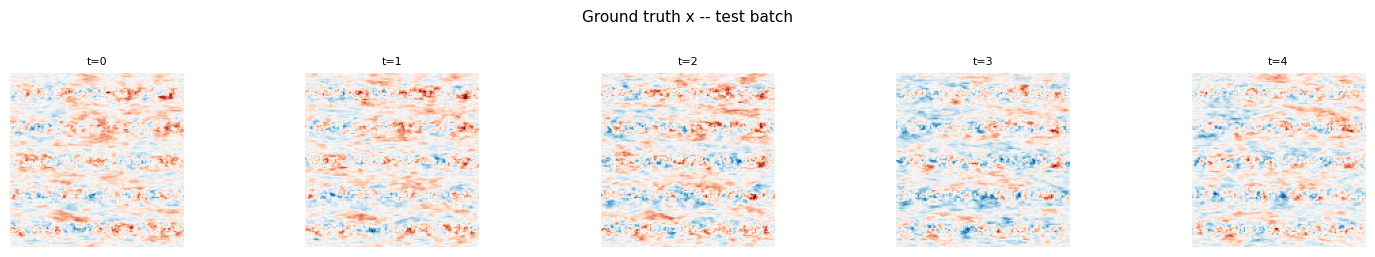

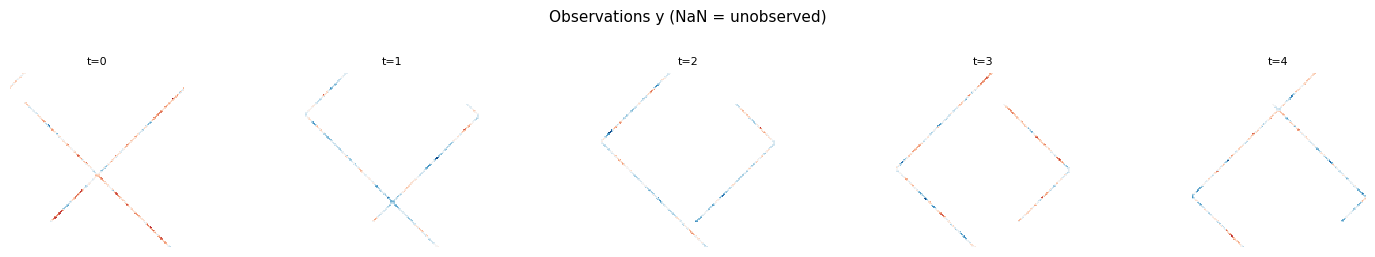

In [14]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    """Display a field (T, H, W) as a grid."""
    T = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


plot_field(batch.tgt[0].float().numpy(),   title="Ground truth x -- test batch")
plot_field(batch.input[0].float().numpy(), title="Observations y (NaN = unobserved)")

### Ensemble Generation (N_SAMPLES members)

Variational sampling:   0%|          | 0/15 [00:00<?, ?it/s]

  Sample 10/10 done
[OK] 10 ensemble members generated
  Sample 10/10 done
[OK] 10 ensemble members generated


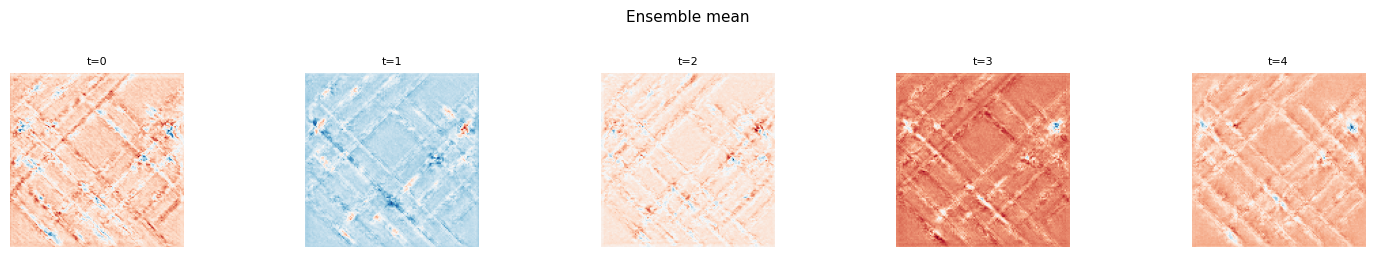

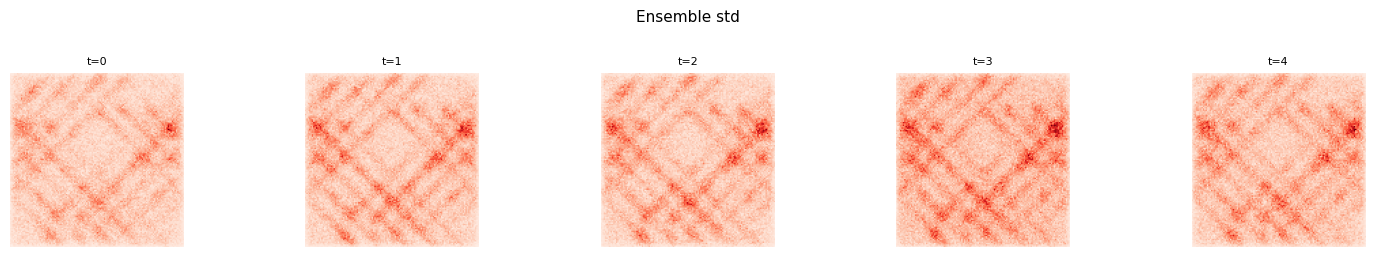

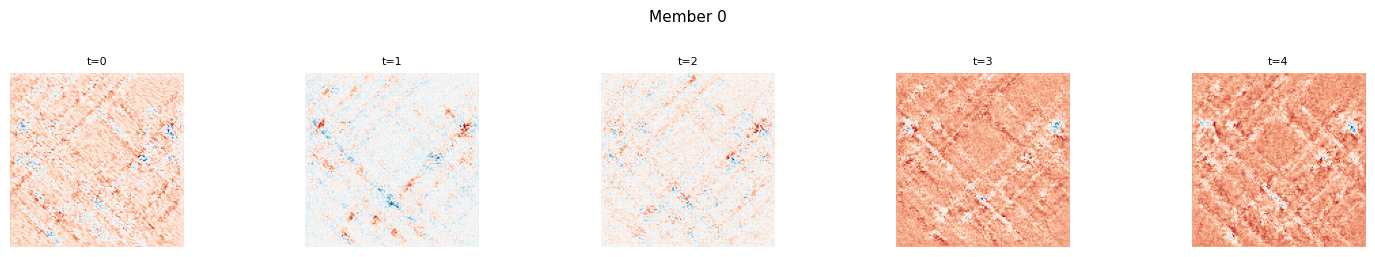

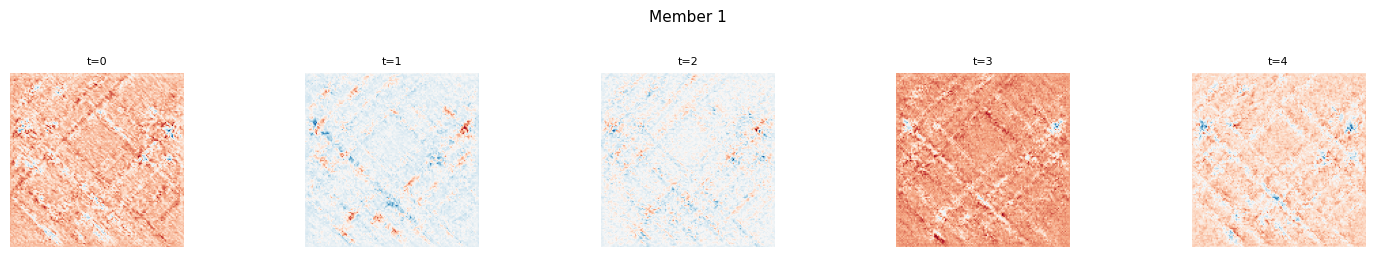

In [16]:
N_SAMPLES = 10
NSTEPS    = 15
variational_sampling = VariationalConsistencySampling(sigma_noise=80.0,
                                                      noise_schedule="cosine", 
                                                      conditioning_mode="obs",
                                                      schedule_power=SCHEDULE_POWER)

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]

samples   = []
samples_process = []

y_dev = batch.input.to(device=device, dtype=dtype)

with torch.no_grad():
    for i in range(N_SAMPLES):
        noise = torch.randn((1, C, H, W), device=device, dtype=dtype)
        sample, sample_process = variational_sampling(
            unet,
            obs_cost,
            prior_cost,
            lambda_reg,
            noise,
            y_dev,
            nsteps=NSTEPS,
            clip_denoised=False,
            verbose=(i == 0),
        )
        samples.append(sample.float().cpu())
        samples_process.append(sample_process.float().cpu())
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n[OK] {N_SAMPLES} ensemble members generated")

ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)
ens_std  = ensemble.std(dim=0)

plot_field(ens_mean.numpy(),        title="Ensemble mean")
plot_field(ens_std.numpy(),         title="Ensemble std", vmin=0, cmap="Reds")
plot_field(samples[0][0].numpy(),   title="Member 0")
plot_field(samples[1][0].numpy(),   title="Member 1")

## Metrics -- VariationalCM vs OI

- **mu-score** = $1 - \text{RMSE}/\sigma_{\text{GT}}$ (higher is better)
- **RMSE** (lower is better)
- **CRPS** ensemble (lower is better)
- **lambda_x** -- minimum resolved wavelength (radial PSD)
- **Spread-skill ratio** (ideally ~ 1)

In [17]:
# ---- Denormalization ----
m_norm, s_norm = datamodule.norm_stats()

gt_np       = batch.tgt[0].float().numpy()
ens_mean_np = ens_mean.numpy()
ensemble_np = ensemble.numpy()   # (N, C, H, W)

gt_phys       = gt_np       * s_norm + m_norm
ens_mean_phys = ens_mean_np * s_norm + m_norm
ensemble_phys = ensemble_np * s_norm + m_norm

start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_phys = datamodule.oi[start_t : start_t + ws].astype(np.float32)
oi_norm = (oi_phys - m_norm) / s_norm


def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing="ij")
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred, gt, label, dx=1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt) // 2], psd_pred[:len(psd_pred) // 2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


row_cm, psd_cm, psd_gt_rad = metrics_vs_gt(ens_mean_phys, gt_phys, "VariationalCM (mean)")
row_oi, psd_oi, _           = metrics_vs_gt(oi_phys,        gt_phys, "OI baseline")

rmse_oi_norm = np.sqrt(np.nanmean((oi_norm    - gt_np) ** 2))
rmse_cm_norm = np.sqrt(np.nanmean((ens_mean_np - gt_np) ** 2))
print(f"RMSE VariationalCM (normalized): {rmse_cm_norm:.4f}")
print(f"RMSE OI            (normalized): {rmse_oi_norm:.4f}")

if HAS_PROPERSCORING:
    crps_values = []
    for t in range(gt_phys.shape[0]):
        for i in range(gt_phys.shape[1]):
            for j in range(gt_phys.shape[2]):
                if not np.isnan(gt_phys[t, i, j]):
                    crps_values.append(crps_ensemble(gt_phys[t, i, j], ensemble_phys[:, t, i, j]))
    crps_mean = np.mean(crps_values)
    print(f"CRPS mean (ensemble)  : {crps_mean:.4f}")
else:
    crps_mean = np.nan

df = pd.DataFrame([row_cm, row_oi]).set_index("Method")
df["mu_score"]      = df["mu_score"].map("{:.4f}".format)
df["RMSE"]          = df["RMSE"].map("{:.4f}".format)
df["lambda_x_GT"]   = df["lambda_x_GT"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["lambda_x_pred"] = df["lambda_x_pred"].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
df["spectral_corr"] = df["spectral_corr"].map("{:.4f}".format)
print("\n## Performance Assessment -- VariationalCM vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

rmse_det = np.sqrt(np.nanmean((ens_mean_phys - gt_phys) ** 2))
spread   = np.nanmean(np.std(ensemble_phys, axis=0))
print(f"\nEnsemble spread (mean std): {spread:.4f}")
print(f"RMSE (ensemble mean)     : {rmse_det:.4f}")
print(f"Spread-skill ratio       : {spread / rmse_det:.4f}  (ideal ~ 1.0)")
if not np.isnan(crps_mean):
    print(f"CRPS                     : {crps_mean:.4f}")

/tmp/ipykernel_2888914/584592307.py:34: RuntimeWarning: divide by zero encountered in divide
  lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan


RMSE VariationalCM (normalized): 1.0003
RMSE OI            (normalized): 0.8942
CRPS mean (ensemble)  : 0.1785

## Performance Assessment -- VariationalCM vs OI (SPDE dataset)

| Method               |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| VariationalCM (mean) |    -0.0065 | 0.2492 |           inf |              64 |          0.1219 |
| OI baseline          |     0.1004 | 0.2228 |           inf |             inf |          0.99   |
CRPS mean (ensemble)  : 0.1785

## Performance Assessment -- VariationalCM vs OI (SPDE dataset)

| Method               |   mu_score |   RMSE |   lambda_x_GT |   lambda_x_pred |   spectral_corr |
|:---------------------|-----------:|-------:|--------------:|----------------:|----------------:|
| VariationalCM (mean) |    -0.0065 | 0.2492 |           inf |              64 |          0.1219 |
| OI baseline          |     0.10

,mu_score,RMSE,lambda_x_GT,lambda_x_pred,spectral_corr
Method,,,,,
VariationalCM (mean),-0.0065,0.2492,inf,64.00,0.1219
OI baseline,0.1004,0.2228,inf,inf,0.9900



Ensemble spread (mean std): 0.0310
RMSE (ensemble mean)     : 0.2492
Spread-skill ratio       : 0.1242  (ideal ~ 1.0)
CRPS                     : 0.1785


### Radial PSD -- VariationalCM vs OI vs GT

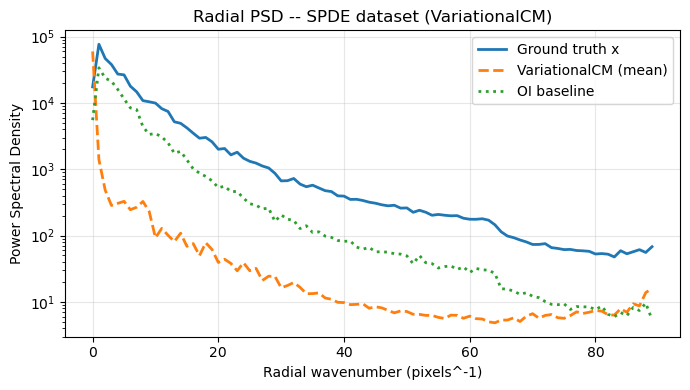

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt_rad, label="Ground truth x",         linewidth=2)
ax.semilogy(psd_cm,      label="VariationalCM (mean)",   linewidth=2, linestyle="--")
ax.semilogy(psd_oi,      label="OI baseline",             linewidth=2, linestyle=":")
ax.set_xlabel("Radial wavenumber (pixels^-1)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD -- SPDE dataset (VariationalCM)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Comparison -- GT / OI / Prior Phi(x) / VariationalCM

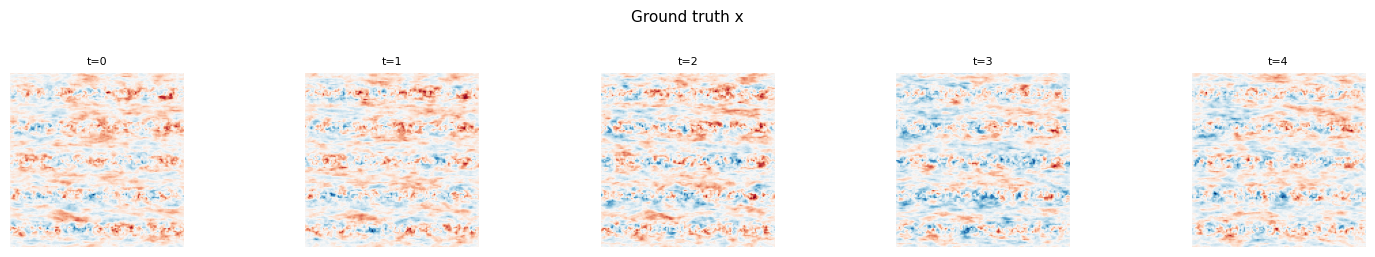

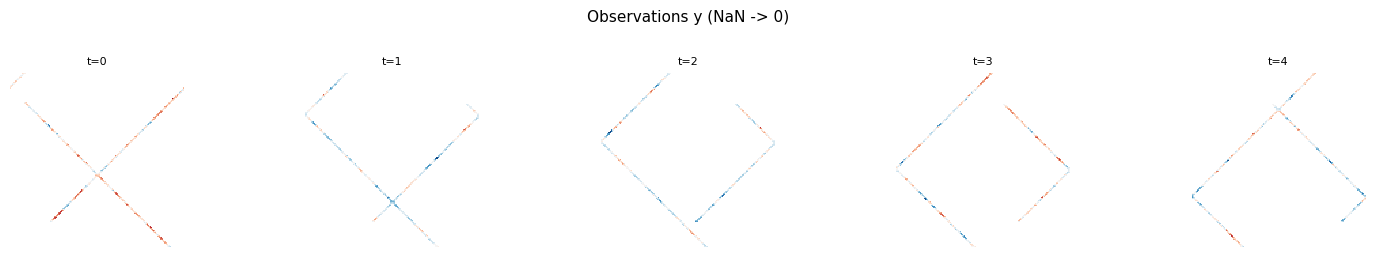

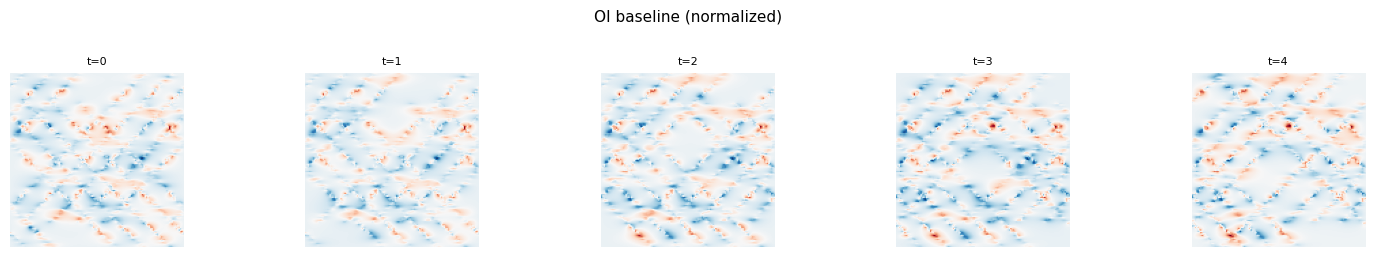

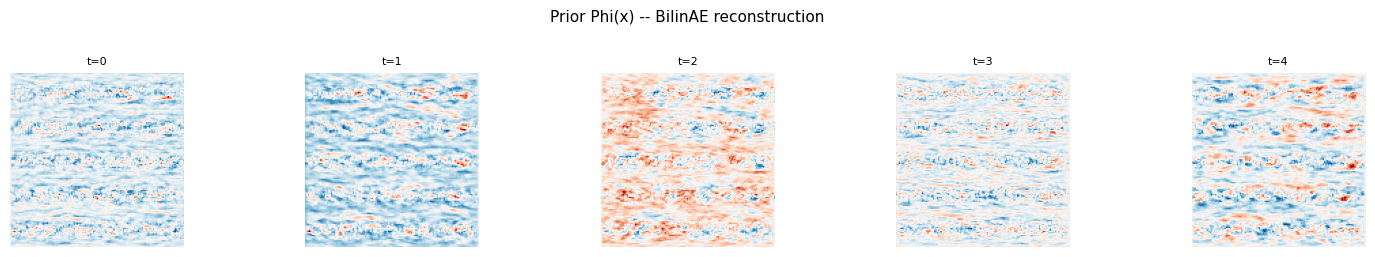

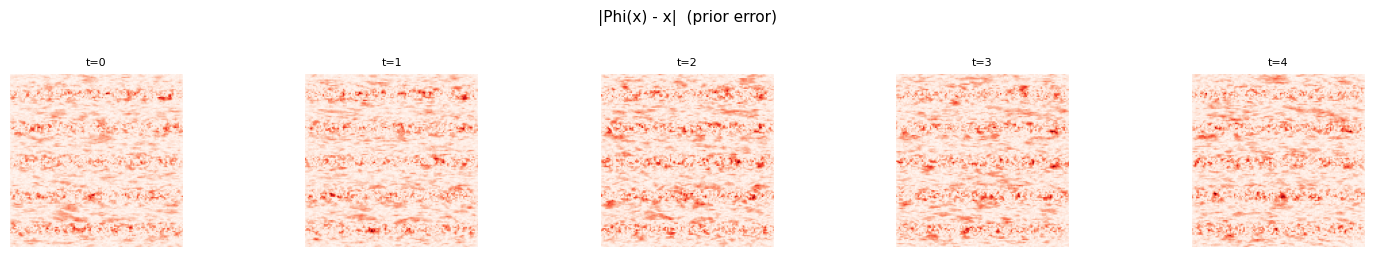

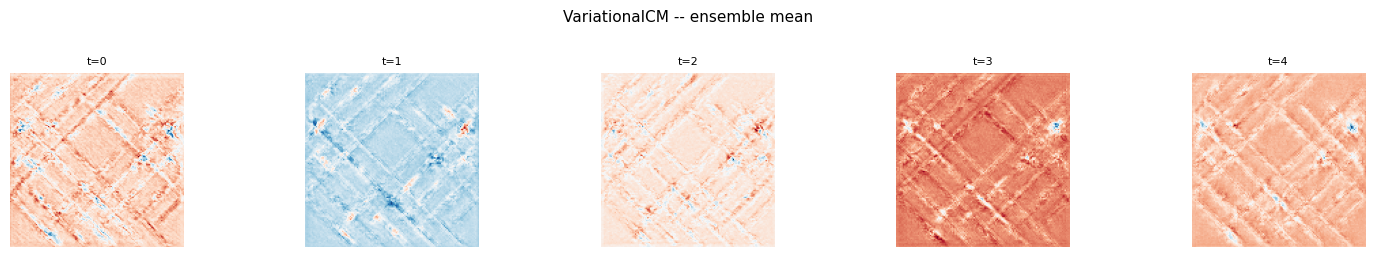

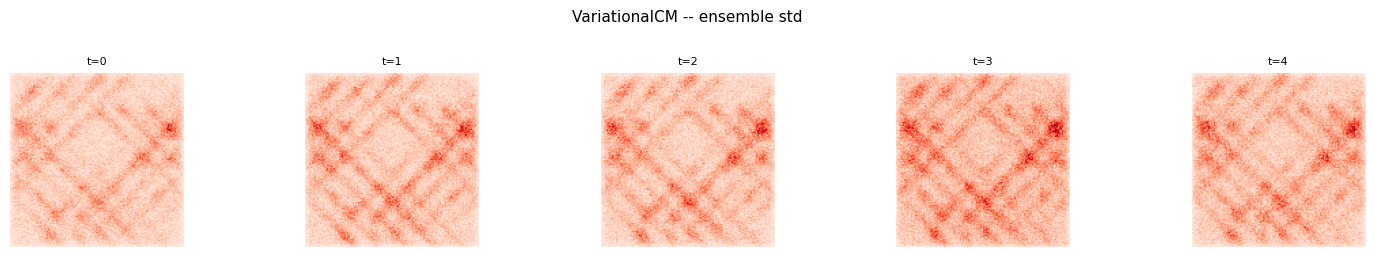

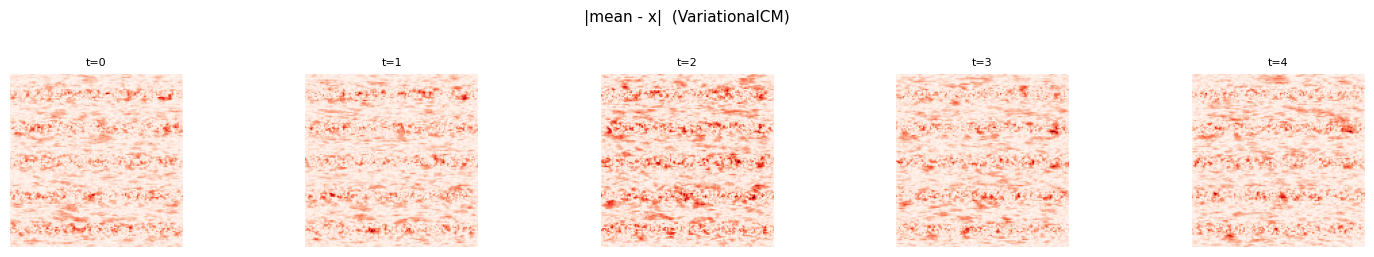

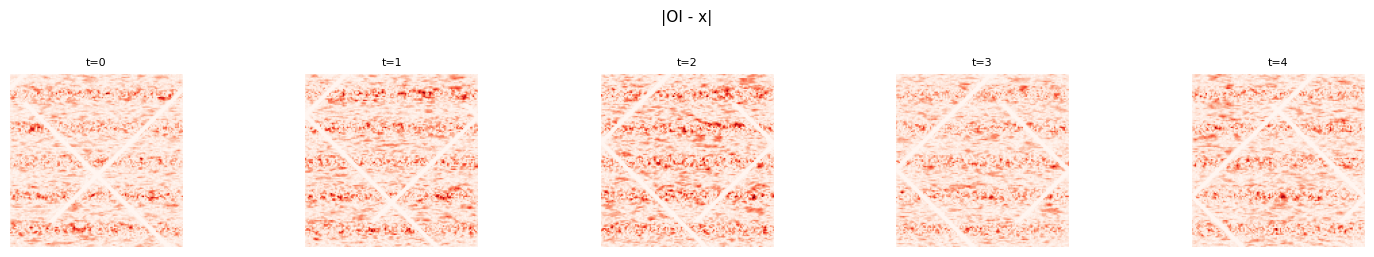

In [19]:
# Prior Phi(x) -- BilinAE reconstruction applied to ground truth
with torch.no_grad():
    tgt_recon = prior_cost.forward_ae(
        batch.tgt.to(device=device, dtype=dtype)
    ).float().cpu()[0]   # (C, H, W)
tgt_recon_np = tgt_recon.numpy()

plot_field(gt_np,                                               title="Ground truth x")
plot_field(batch.input[0].float().numpy(),                      title="Observations y (NaN -> 0)")
plot_field(oi_norm,                                             title="OI baseline (normalized)")
plot_field(tgt_recon_np,                                        title="Prior Phi(x) -- BilinAE reconstruction")
plot_field(np.abs(tgt_recon_np - gt_np),                        title="|Phi(x) - x|  (prior error)",              vmin=0, cmap="Reds")
plot_field(ens_mean_np,                                         title="VariationalCM -- ensemble mean")
plot_field(ens_std.numpy(),                                     title="VariationalCM -- ensemble std",             vmin=0, cmap="Reds")
plot_field(np.abs(ens_mean_np - gt_np),                         title="|mean - x|  (VariationalCM)",              vmin=0, cmap="Reds")
plot_field(np.abs(oi_norm     - gt_np),                         title="|OI - x|",                              vmin=0, cmap="Reds")

### Transport process -- member 0 (sampling steps)

/tmp/ipykernel_2888914/3287129061.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.95])


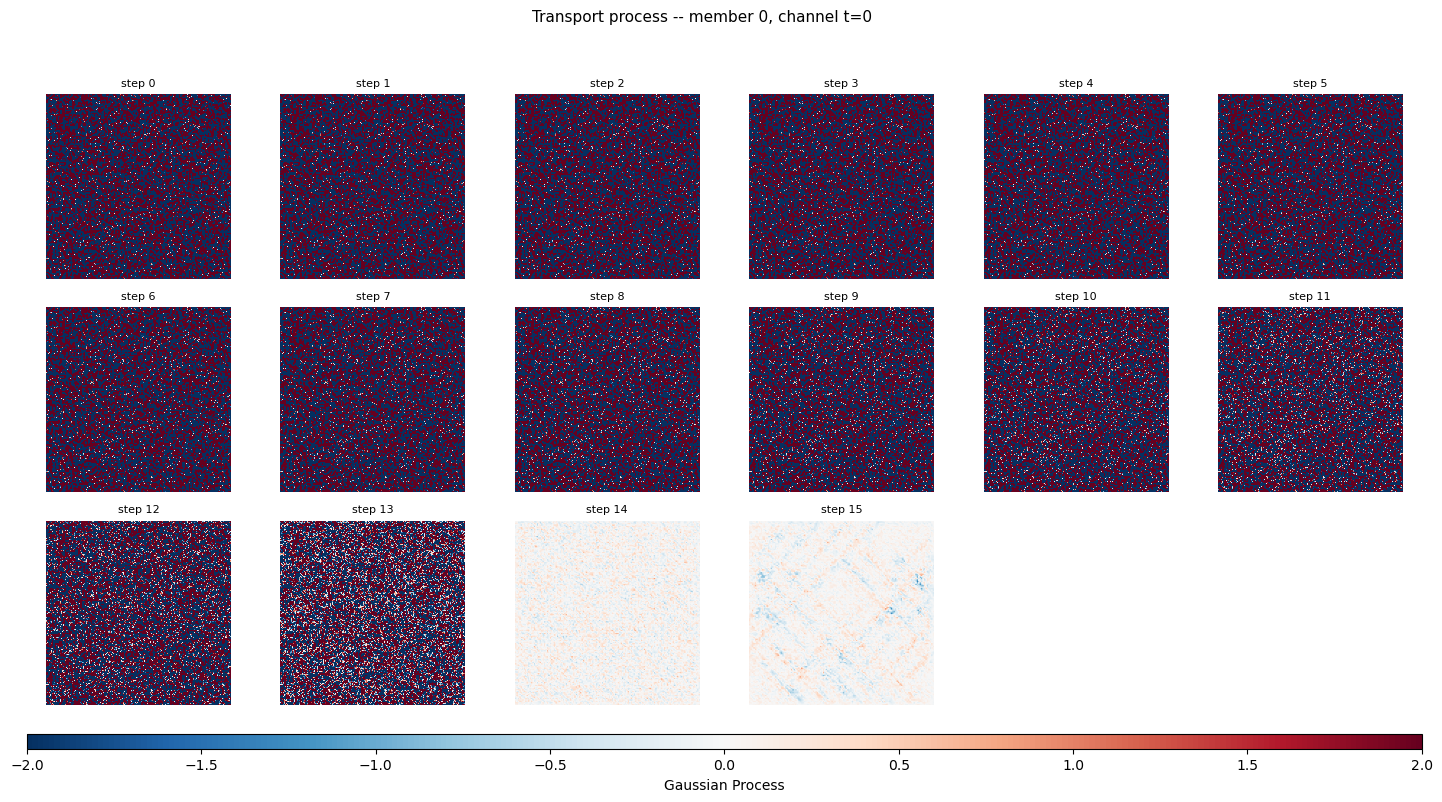

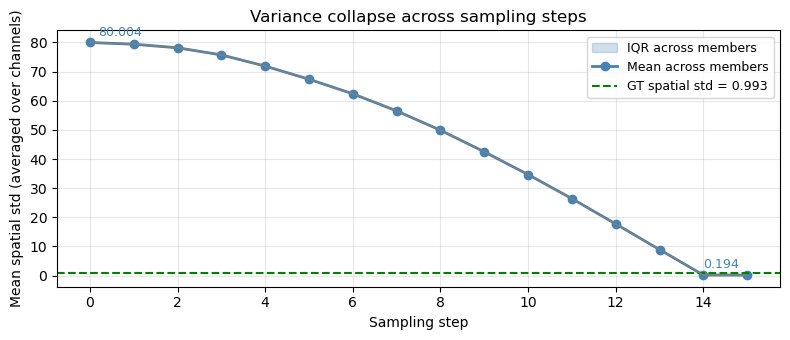

Std at step 0 (pure noise) : 80.0040  (expected ~ 15*sigma_noise if unnormed)
Std at step 15 (final)      : 0.1939
Collapse factor            : 412.69x

--- Spatial std reference (single realization, mean over C channels) ---
  GT spatial std           : 0.9935
  CM final spatial std     : 0.1939
  Ratio CM/GT              : 0.195  (ideal ~ 1.0)

NOTE: Dataset std=1 is over ALL samples×pixels. The spatial std of a single
      SPDE realization (std over H×W) can naturally be much less than 1.
      The relevant check is CM_final_std / GT_spatial_std ~ 1.0


In [20]:

# samples_process[0]: Tensor (nsteps+1, 1, C, H, W)
# Display the evolution of t=0 (channel 0) across sampling steps
process_t0 = samples_process[0][:, 0, 0, :, :]   # (nsteps+1, H, W)
process_np = process_t0.numpy()

vmin = -2
vmax = 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math

nsteps_vis = process_np.shape[0]
cols = min(nsteps_vis, 6)
rows = math.ceil(nsteps_vis / cols)

fig = plt.figure(figsize=(3 * cols, 2.5 * rows + 1))

gs = gridspec.GridSpec(
    rows + 1, cols,
    height_ratios=[*([1] * rows), 0.08],
    hspace=0.2,
    wspace=0.05
)

axes = []
for i in range(rows):
    for j in range(cols):
        axes.append(fig.add_subplot(gs[i, j]))

cax = fig.add_subplot(gs[rows, :])

for k in range(nsteps_vis):
    im = axes[k].imshow(
        process_np[k],
        origin="lower",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )
    axes[k].set_title(f"step {k}", fontsize=8)
    axes[k].axis("off")

for ax in axes[nsteps_vis:]:
    ax.axis("off")

cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
cbar.set_label("Gaussian Process")

fig.suptitle("Transport process -- member 0, channel t=0", fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

# ---- Std decay curve across sampling steps ----
step_stds_all = np.array([
    [
        proc[k, 0].numpy().std(axis=(-2, -1)).mean()  # mean over C channels
        for k in range(nsteps_vis)
    ]
    for proc in samples_process   # one per member
])   # shape: (N_SAMPLES, nsteps+1)

step_stds_mean = step_stds_all.mean(axis=0)   # (nsteps+1,)
step_stds_q25  = np.percentile(step_stds_all, 25, axis=0)
step_stds_q75  = np.percentile(step_stds_all, 75, axis=0)

steps = np.arange(nsteps_vis)

# ---- Reference: spatial std of GT and noise (for interpretation) ----
gt_spatial_std   = batch.tgt[0].float().numpy().std(axis=(-2, -1)).mean()   # mean over C
noise_spatial_std = step_stds_mean[0]   # initial state (sigma_noise * randn)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(steps, step_stds_q25, step_stds_q75,
                alpha=0.25, color="steelblue", label="IQR across members")
ax.plot(steps, step_stds_mean, marker="o", linewidth=2,
        color="steelblue", label="Mean across members")
# GT spatial std reference line
ax.axhline(gt_spatial_std, color="green", linewidth=1.5, linestyle="--",
           label=f"GT spatial std = {gt_spatial_std:.3f}")
# Individual members
for i, row in enumerate(step_stds_all):
    ax.plot(steps, row, linewidth=0.6, alpha=0.4, color="gray")

ax.set_xlabel("Sampling step")
ax.set_ylabel("Mean spatial std (averaged over channels)")
ax.set_title("Variance collapse across sampling steps")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate first and last
ax.annotate(f"{step_stds_mean[0]:.3f}", (0, step_stds_mean[0]),
            textcoords="offset points", xytext=(6, 5), fontsize=9, color="steelblue")
ax.annotate(f"{step_stds_mean[-1]:.3f}", (nsteps_vis - 1, step_stds_mean[-1]),
            textcoords="offset points", xytext=(-32, 5), fontsize=9, color="steelblue")

plt.tight_layout()
plt.show()

print(f"Std at step 0 (pure noise) : {step_stds_mean[0]:.4f}  (expected ~ {NSTEPS}*sigma_noise if unnormed)")
print(f"Std at step {nsteps_vis-1} (final)      : {step_stds_mean[-1]:.4f}")
print(f"Collapse factor            : {step_stds_mean[0] / max(step_stds_mean[-1], 1e-8):.2f}x")
print()
print("--- Spatial std reference (single realization, mean over C channels) ---")
print(f"  GT spatial std           : {gt_spatial_std:.4f}")
print(f"  CM final spatial std     : {step_stds_mean[-1]:.4f}")
print(f"  Ratio CM/GT              : {step_stds_mean[-1] / max(gt_spatial_std, 1e-8):.3f}  (ideal ~ 1.0)")
print()
print("NOTE: Dataset std=1 is over ALL samples×pixels. The spatial std of a single")
print("      SPDE realization (std over H×W) can naturally be much less than 1.")
print("      The relevant check is CM_final_std / GT_spatial_std ~ 1.0")


---

## 3. Stochastic VarCM — Isotropic Covariance

*(Implements Section 2.3 above)*

We retain the same pairwise structure but make $G_\phi$ predict Gaussian parameters:

$$
G_\phi(\mathbf{x}_t, t, t') = \bigl(\boldsymbol{\mu}_\phi(\mathbf{x}_t,t,t'),\; \sigma_\phi(\mathbf{x}_t,t,t')\bigr)
$$

The stochastic transition is:

$$
\mathbf{x}_{t'} = \underbrace{c_\text{skip}\,\mathbf{x}_t + c_\text{out}\,\boldsymbol{\mu}_\phi}_{\text{mean}} + \underbrace{\sigma_\phi\,\boldsymbol{\varepsilon}}_{\text{noise}},
\quad \boldsymbol{\varepsilon}\sim\mathcal{N}(0,\mathbf{I})
$$

### Loss

$$
\mathcal{L}_\text{SDE} = \mathcal{L}_\text{comp} + \lambda_\text{anc}\,\mathcal{L}_\text{anc}
$$

**$\mathcal{L}_\text{comp}$** — pairwise consistency on means (teacher/student, same as deterministic Term 1).  
**$\mathcal{L}_\text{anc}$** — isotropic NLL anchoring from two chains:

$$
\mathcal{L}_\text{anc} =
\underbrace{\mathbb{E}_{\mathbf{x}_T,t}\!\left[\frac{\|\mathbf{x}_0 - \boldsymbol{\mu}_{T\to t\to 0}\|^2}{2\sigma^2_{T,t,0}} + \frac{d}{2}\log\sigma^2_{T,t,0}\right]}_{\text{long-chain NLL}}
+
\underbrace{\mathbb{E}_{t,t'}\!\left[\frac{\|\mathbf{x}_0 - \boldsymbol{\mu}_{t\to t'\to 0}\|^2}{2\sigma^2_{t,t',0}} + \frac{d}{2}\log\sigma^2_{t,t',0}\right]}_{\text{short-chain NLL}}
$$

The NLL forces the predicted $\sigma$ to calibrate to the actual reconstruction error.

### Sampling

| Mode | Update | Uncertainty |
|------|--------|-------------|
| **ODE** (`stoch=False`) | $\mathbf{x}_{t'} = c_\text{skip}\mathbf{x}_t + c_\text{out}\boldsymbol{\mu}_\phi$ | None — converges to MAP |
| **SDE** (`stoch=True`)  | $\mathbf{x}_{t'} = c_\text{skip}\mathbf{x}_t + c_\text{out}\boldsymbol{\mu}_\phi + \sigma_\phi\,\boldsymbol{\varepsilon}$ | Posterior sampling |


In [ ]:
# ============================================================
# Stochastic VarCM -- helpers
# ============================================================

import importlib
import consistency_models.consistency_models_VarCM as _vcm
importlib.reload(_vcm)
from consistency_models.consistency_models_VarCM import (
    LinearSchedule, DEFAULT_SCHEDULE,
    VariationalConsistencyTraining,
)
from consistency_models.utils import karras_schedule, timesteps_schedule, update_ema_model_
from consistency_models.consistency_models_CM import ema_decay_rate_schedule


# -------------------------------------------------------
# Forward wrapper for stochastic UNet
# -------------------------------------------------------

def stoch_forward(
    model: nn.Module,
    obs_cost: nn.Module,
    prior_cost: nn.Module,
    lambda_reg: nn.Parameter,
    x: Tensor,            # (B, C, H, W)  current state
    y: Tensor,            # (B, C, H, W)  observations
    t: Tensor,            # (B,)  source time in [0, 1]
    t_prime: Tensor,      # (B,)  target time in [0, 1]
    schedule=None,
    sigma_noise: float = 1.0,
    conditioning_mode: str = "obs",
    z: Optional[Tensor] = None,   # None -> ODE (deterministic mean); Tensor -> SDE
) -> Tuple[Tensor, Tensor, Tensor]:
    """
    Stochastic pairwise transport operator.

    Returns
    -------
    x_out      : (B, C, H, W)  transported state (mean if z=None, mean+σε if z given)
    log_sigma  : (B, 1)        scalar log σ predicted by the UNet
    cond       : (B, ?, H, W)  conditioning signal (grad_J or obs cat)
    """
    if schedule is None:
        schedule = DEFAULT_SCHEDULE

    B, C, H, W = x.shape

    # --- Build conditioning (same as deterministic wrapper) ---
    if conditioning_mode == "obs":
        mask   = (~torch.isnan(y)).to(dtype=x.dtype)
        y_fill = torch.nan_to_num(y, nan=0.0).to(dtype=x.dtype)
        cond   = torch.cat([y_fill, mask], dim=1)   # (B, 2C, H, W)
    else:
        x_leaf = x.detach().float().requires_grad_(True)
        y_c    = y.detach().float()
        lr_f   = lambda_reg.detach().float().clamp(min=0.0)
        try:
            cost_dtype = next(prior_cost.parameters()).dtype
        except StopIteration:
            cost_dtype = torch.float32
        with torch.enable_grad():
            Jo = obs_cost(x_leaf.to(cost_dtype), y_c.to(cost_dtype))
            Jb = prior_cost(x_leaf.to(cost_dtype))
            J  = (Jo + lr_f.to(cost_dtype) * Jb).float()
            g  = torch.autograd.grad(J, x_leaf, create_graph=False)[0].detach()
        cond = (g / g.std().clamp(min=1e-8)).to(dtype=x.dtype)

    x_det = x.detach()

    # --- Preconditioning scalars ---
    def _expand(s: Tensor) -> Tensor: return s.view(B, 1, 1, 1)
    c_in   = _expand(schedule.c_in(t,        sigma_noise))
    c_skip = _expand(schedule.c_skip(t,       t_prime))
    c_out  = _expand(schedule.c_out(t,        t_prime))

    # --- Network forward (stoch=True returns (mu, log_sigma)) ---
    F_mu, log_sigma = model(c_in * x_det, cond, t, t_prime)   # (B,C,H,W), (B,1)

    x_mean = c_skip * x_det + c_out * F_mu                    # deterministic mean

    if z is not None:
        sigma = torch.exp(log_sigma).view(B, 1, 1, 1)         # (B,1,1,1) scalar
        x_out = x_mean + sigma * z
    else:
        x_out = x_mean

    return x_out, log_sigma, cond


# -------------------------------------------------------
# Isotropic Gaussian NLL  (anchoring loss)
# -------------------------------------------------------

def anchoring_nll_iso(
    x0: Tensor,         # (B, C, H, W) ground truth
    mu: Tensor,         # (B, C, H, W) predicted mean
    log_sigma: Tensor,  # (B, 1)       scalar log σ per sample
) -> Tensor:
    """
    L_anc = ||x0 - mu||^2 / (2 σ^2)  +  (d/2) log σ^2

    Returns scalar mean over the batch.
    """
    B, C, H, W = x0.shape
    d = C * H * W
    sigma2    = torch.exp(2.0 * log_sigma).squeeze(1)      # (B,)
    residual  = (x0 - mu).pow(2).reshape(B, -1).sum(1)    # (B,)  sum over d
    nll       = residual / (2.0 * sigma2 + 1e-8) + (d / 2.0) * torch.log(sigma2 + 1e-8)
    return nll.mean()


# -------------------------------------------------------
# Stochastic VarCM training step
# -------------------------------------------------------

@dataclass
class StochVarCMOutput:
    loss:          Tensor
    l_comp:        Tensor
    l_anc:         Tensor
    num_timesteps: int


class StochasticVarCMTraining(nn.Module):
    """
    Pairwise self-consistency training for stochastic VarCM (isotropic covariance).

    Loss = L_comp  +  lambda_anc * L_anc

    L_comp : composition consistency on *deterministic* means (student vs teacher,
             same teacher-EMA trick as the ODE case). Stabilises the mean dynamics.

    L_anc  : isotropic Gaussian NLL anchoring to x0, from two chains:
               (1)  x_T  -> g_stoch(x_T, T, 0)  -> x0
               (2)  x_t  -> g_stoch(x_t, t, 0)  -> x0   (t from schedule)
             This calibrates σ_φ to match the actual reconstruction error.
    """

    def __init__(
        self,
        initial_timesteps: int   = 5,
        final_timesteps:   int   = 17,
        sigma_noise:       float = 80.0,
        lambda_comp:       float = 1.0,
        lambda_anc:        float = 1.0,
        schedule_power:    float = 1.0,
        conditioning_mode: str   = "obs",
    ) -> None:
        super().__init__()
        self.initial_timesteps = initial_timesteps
        self.final_timesteps   = final_timesteps
        self.sigma_noise       = sigma_noise
        self.lambda_comp       = lambda_comp
        self.lambda_anc        = lambda_anc
        self.schedule_power    = schedule_power
        self.conditioning_mode = conditioning_mode

    def forward(
        self,
        student: nn.Module,
        teacher: nn.Module,
        obs_cost:   nn.Module,
        prior_cost: nn.Module,
        lambda_reg: nn.Parameter,
        x0: Tensor,   # (B, C, H, W)  ground truth
        y:  Tensor,   # (B, C, H, W)  observations
        global_step: int,
        total_steps: int,
    ) -> StochVarCMOutput:
        device = x0.device
        B, C, H, W = x0.shape

        # ---- Dynamic time grid (same schedule as deterministic VarCM) ----
        N = timesteps_schedule(
            global_step,
            total_steps,
            self.initial_timesteps,
            self.final_timesteps,
        )
        times = karras_schedule(
            N,
            sigma_min=0.002 / self.sigma_noise,
            sigma_max=1.0,
            rho=7.0,
            device=device,
        )
        # Apply power-law warping (same as in VariationalConsistencyTraining)
        times = times ** self.schedule_power
        times = times.clamp(0.0, 1.0)
        # Ensure t=0 is always included
        if times[-1].item() > 0.01:
            times = torch.cat([times, torch.zeros(1, device=device)])

        T_max = times[0].item()   # largest time on the grid

        # ---- Sample three ordered time indices: t > t' > t'' ----
        idx = torch.randperm(len(times) - 1, device=device)[:3].sort().values
        i, j, k = idx[2].item(), idx[1].item(), idx[0].item()   # i > j > k
        t_s   = times[i].expand(B)
        t_p   = times[j].expand(B)
        t_pp  = times[k].expand(B)
        T_vec = torch.full((B,), T_max, device=device, dtype=x0.dtype)

        schedule = DEFAULT_SCHEDULE

        # ---- Build noisy states from the interpolant ----
        z_noise = torch.randn_like(x0)
        alpha_t  = schedule.alpha(t_s).view(B, 1, 1, 1)
        beta_t   = schedule.beta(t_s).view(B, 1, 1, 1)
        x_T_     = torch.randn_like(x0) * self.sigma_noise   # x_T ~ N(0, σ_noise² I)
        x_t_noisy = alpha_t * x_T_ + beta_t * x0             # interpolant at t

        # ==============================================================
        # L_comp: composition consistency (deterministic means, ODE mode)
        # ==============================================================
        # Student: h_t  -> g_student(h_t,  t,  t'')
        # Teacher: h_t' -> g_teacher(h_t', t', t'')   (stop-grad)

        # Teacher: h_t = g_teacher(x_T, T, t),  h_t' = g_teacher(x_T, T, t')
        with torch.no_grad():
            h_t,  _, _ = stoch_forward(teacher, obs_cost, prior_cost, lambda_reg,
                                        x_T_, y, T_vec, t_s,
                                        sigma_noise=self.sigma_noise,
                                        conditioning_mode=self.conditioning_mode)
            h_tp, _, _ = stoch_forward(teacher, obs_cost, prior_cost, lambda_reg,
                                        x_T_, y, T_vec, t_p,
                                        sigma_noise=self.sigma_noise,
                                        conditioning_mode=self.conditioning_mode)
            out_tp_teacher, _, _ = stoch_forward(teacher, obs_cost, prior_cost, lambda_reg,
                                                  h_tp, y, t_p, t_pp,
                                                  sigma_noise=self.sigma_noise,
                                                  conditioning_mode=self.conditioning_mode)

        out_t_student, _, _ = stoch_forward(student, obs_cost, prior_cost, lambda_reg,
                                             h_t, y, t_s, t_pp,
                                             sigma_noise=self.sigma_noise,
                                             conditioning_mode=self.conditioning_mode)

        l_comp = F.mse_loss(out_t_student, out_tp_teacher.detach())

        # ==============================================================
        # L_anc: isotropic Gaussian NLL anchoring to x0
        # chain 1: x_T -> g_stoch(x_T, T, 0)  (long chain)
        # chain 2: x_t -> g_stoch(x_t, t, 0)  (short chain, t sampled above)
        # ==============================================================
        t0_vec = torch.zeros(B, device=device, dtype=x0.dtype) + 1e-3

        # Chain 1: x_T -> x_0
        mu_T, log_sig_T, _ = stoch_forward(student, obs_cost, prior_cost, lambda_reg,
                                             x_T_, y, T_vec, t0_vec,
                                             sigma_noise=self.sigma_noise,
                                             conditioning_mode=self.conditioning_mode)
        l_anc1 = anchoring_nll_iso(x0, mu_T, log_sig_T)

        # Chain 2: x_t -> x_0
        mu_t, log_sig_t, _ = stoch_forward(student, obs_cost, prior_cost, lambda_reg,
                                             x_t_noisy, y, t_s, t0_vec,
                                             sigma_noise=self.sigma_noise,
                                             conditioning_mode=self.conditioning_mode)
        l_anc2 = anchoring_nll_iso(x0, mu_t, log_sig_t)

        l_anc = 0.5 * (l_anc1 + l_anc2)

        loss = self.lambda_comp * l_comp + self.lambda_anc * l_anc

        return StochVarCMOutput(
            loss=loss,
            l_comp=l_comp,
            l_anc=l_anc,
            num_timesteps=N,
        )


# Sanity check
C = datamodule.window_size
_stoch_ct = StochasticVarCMTraining(
    initial_timesteps=3,
    final_timesteps=5,
    sigma_noise=80.0,
    lambda_comp=1.0,
    lambda_anc=1.0,
    conditioning_mode="obs",
)
_unet_s   = UNet(UNetConfig(channels=C, stoch=True))
_teacher_s = UNet(UNetConfig(channels=C, stoch=True))
_teacher_s.load_state_dict(_unet_s.state_dict())
_obs   = BaseObsCost(sigma_obs=1.0)
_prior = BilinAEPriorCost(dim_in=C)
_lr    = nn.Parameter(torch.tensor(1.0))
_batch = next(iter(datamodule.train_dataloader()))
with torch.no_grad():
    _out = _stoch_ct(_unet_s, _teacher_s, _obs, _prior, _lr,
                     _batch.tgt, _batch.input, global_step=0, total_steps=5000)
print(f"[OK] StochasticVarCMTraining sanity: loss={_out.loss.item():.4f}  "
      f"l_comp={_out.l_comp.item():.4f}  l_anc={_out.l_anc.item():.4f}  N={_out.num_timesteps}")
del _unet_s, _teacher_s, _obs, _prior, _lr, _batch, _out


In [ ]:
# ============================================================
# LitStochasticVarCM -- LightningModule
# ============================================================

@dataclass
class LitStochVarCMConfig:
    initial_ema_decay_rate:      float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr:                          float = 1e-4
    betas:        Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor:   float = 1e-5
    lr_scheduler_iters:          int   = 10_000
    lambda_reg_init:             float = 1.0
    total_training_steps:        int   = 5_000


class LitStochasticVarCM(LightningModule):
    """
    Lightning wrapper for Stochastic VarCM (isotropic covariance).

    Architecture:  UNet(stoch=True) -> outputs (mu, log_sigma)
    Loss:          L_SDE = lambda_comp * L_comp  +  lambda_anc * L_anc
    Sampling:      stoch=False -> ODE (deterministic mean)
                   stoch=True  -> SDE (add σ * ε at each step)
    """

    def __init__(
        self,
        stoch_training:    StochasticVarCMTraining,
        student_model:     UNet,   # must have config.stoch=True
        teacher_model:     UNet,
        ema_student_model: UNet,
        obs_cost:          BaseObsCost,
        prior_cost:        BilinAEPriorCost,
        config:            LitStochVarCMConfig,
    ) -> None:
        super().__init__()
        self.stoch_training    = stoch_training
        self.student_model     = student_model
        self.teacher_model     = teacher_model
        self.ema_student_model = ema_student_model
        self.obs_cost          = obs_cost
        self.prior_cost        = prior_cost
        self.config            = config
        self.num_timesteps     = stoch_training.initial_timesteps

        self.lambda_reg = nn.Parameter(
            torch.tensor(config.lambda_reg_init, dtype=torch.float32)
        )

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model.eval()
        self.ema_student_model.eval()

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] N={self.num_timesteps}  "
              f"λ_reg={self.lambda_reg.item():.4f}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]
        self.lambda_reg.data.clamp_(min=0.0)

        out = self.stoch_training(
            self.student_model,
            self.teacher_model,
            self.obs_cost,
            self.prior_cost,
            self.lambda_reg,
            batch.tgt,
            batch.input,
            self.global_step,
            self.config.total_training_steps,
        )
        self.num_timesteps = out.num_timesteps

        if batch_idx % 20 == 0:
            print(f"  [step {self.global_step}] N={out.num_timesteps}  "
                  f"loss={out.loss.item():.4f}  L_comp={out.l_comp.item():.4f}  "
                  f"L_anc={out.l_anc.item():.4f}")

        self.log_dict({
            "train_loss":    out.loss,
            "L_comp":        out.l_comp,
            "L_anc":         out.l_anc,
            "num_timesteps": float(out.num_timesteps),
            "lambda_reg":    self.lambda_reg.detach(),
        }, prog_bar=False)
        return out.loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_decay = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.stoch_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model,     self.student_model, ema_decay)
        update_ema_model_(self.ema_student_model, self.student_model,
                          self.config.student_model_ema_decay_rate)
        self.log("ema_decay_rate", ema_decay)

    def configure_optimizers(self):
        params = (
            list(self.student_model.parameters())
            + list(self.obs_cost.parameters())
            + list(self.prior_cost.parameters())
            + [self.lambda_reg]
        )
        opt = torch.optim.Adam(params, lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


### Training — Stochastic VarCM


In [ ]:
RESET_TRAINING_STOCH  = False
RESUME_FROM_LAST_STOCH = True

C = datamodule.window_size

LOG_DIR_S     = "logs_CT_VarCM_stoch_spde"
LOG_VERSION_S = "v1"
CKPT_DIR_S    = os.path.join(LOG_DIR_S, LOG_VERSION_S, "checkpoints")
MODEL_PATH_S  = os.path.join(LOG_DIR_S, LOG_VERSION_S, "best_model")

if RESET_TRAINING_STOCH:
    import shutil
    for d in [CKPT_DIR_S, MODEL_PATH_S]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt_s = None
    print("[RESET] Stochastic VarCM: starting from scratch.")
else:
    resume_ckpt_s = find_best_valid_checkpoint(CKPT_DIR_S, use_last=RESUME_FROM_LAST_STOCH)

SCHEDULE_POWER_S = 1.0

stoch_ct = StochasticVarCMTraining(
    initial_timesteps = 5,
    final_timesteps   = 17,
    sigma_noise       = 80.0,
    lambda_comp       = 1.0,
    lambda_anc        = 0.5,    # weight for NLL anchoring
    schedule_power    = SCHEDULE_POWER_S,
    conditioning_mode = "obs",
)

# Stochastic models (stoch=True)
student_s     = UNet(UNetConfig(channels=C, stoch=True))
teacher_s     = UNet(UNetConfig(channels=C, stoch=True))
ema_student_s = UNet(UNetConfig(channels=C, stoch=True))
teacher_s.load_state_dict(student_s.state_dict())
ema_student_s.load_state_dict(student_s.state_dict())

obs_cost_s   = BaseObsCost(sigma_obs=1.0)
prior_cost_s = BilinAEPriorCost(dim_in=C)

lit_stoch = LitStochasticVarCM(
    stoch_ct,
    student_s,
    teacher_s,
    ema_student_s,
    obs_cost_s,
    prior_cost_s,
    LitStochVarCMConfig(lr_scheduler_iters=1000, total_training_steps=5000),
)

trainer_s = Trainer(
    accelerator  = "gpu",
    max_epochs   = 2500,
    accumulate_grad_batches = 4,
    precision    = "bf16-mixed",
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    log_every_n_steps = 1,
    logger   = TensorBoardLogger(".", name=LOG_DIR_S, version=LOG_VERSION_S),
    callbacks = [
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath  = CKPT_DIR_S,
            monitor  = "train_loss",
            save_top_k = 3,
            save_last  = True,
            filename = "{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer_s.fit(lit_stoch, datamodule, ckpt_path=resume_ckpt_s)

# Save EMA model + costs
lit_stoch.ema_student_model.save_pretrained(MODEL_PATH_S)
torch.save(
    {
        "obs_cost":       lit_stoch.obs_cost.state_dict(),
        "prior_cost":     lit_stoch.prior_cost.state_dict(),
        "lambda_reg":     lit_stoch.lambda_reg.detach().cpu(),
        "schedule_power": SCHEDULE_POWER_S,
    },
    os.path.join(MODEL_PATH_S, "costs.pt"),
)
print(f"[OK] Stochastic VarCM EMA model saved to: {MODEL_PATH_S}")


### Sampling — Stochastic VarCM (ODE vs SDE)


In [ ]:
device  = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype   = torch.bfloat16 if torch.cuda.is_available() else torch.float32
C       = datamodule.window_size

# Load stochastic EMA model
unet_s = UNet.from_pretrained(MODEL_PATH_S).eval().to(device=device, dtype=dtype)

_costs_s = torch.load(os.path.join(MODEL_PATH_S, "costs.pt"), map_location="cpu")
obs_cost_s2   = BaseObsCost(sigma_obs=1.0).to(device=device, dtype=dtype)
prior_cost_s2 = BilinAEPriorCost(dim_in=C).to(device=device, dtype=dtype)
obs_cost_s2.load_state_dict(_costs_s["obs_cost"])
prior_cost_s2.load_state_dict(_costs_s["prior_cost"])
obs_cost_s2.eval();  prior_cost_s2.eval()
lambda_reg_s = nn.Parameter(_costs_s["lambda_reg"].to(device=device, dtype=torch.float32))
SCHED_POW_S  = _costs_s.get("schedule_power", 1.0)

print(f"[OK] Stochastic model loaded: {MODEL_PATH_S}  λ_reg={lambda_reg_s.item():.4f}")


# -------------------------------------------------------
# Sampling loop  (ODE and SDE share the same code,
# controlled by stoch=False/True)
# -------------------------------------------------------

def sample_stoch_varcm(
    unet:      nn.Module,
    obs_cost:  nn.Module,
    prior_cost: nn.Module,
    lambda_reg: nn.Parameter,
    y:         Tensor,         # (1, C, H, W)
    nsteps:    int   = 15,
    sigma_noise: float = 80.0,
    stoch:     bool  = False,  # False -> ODE (mean only);  True -> SDE (+ σ ε)
    schedule_power: float = 1.0,
    clip_denoised: bool = False,
) -> Tuple[Tensor, List[Tensor]]:
    """
    One-pass sampling from x_T down to x_0.

    Returns (final: (1,C,H,W), trajectory: list of (1,C,H,W) at each step).
    """
    B, C, H, W = y.shape
    schedule = DEFAULT_SCHEDULE

    # Build time grid (same as training)
    times = karras_schedule(
        nsteps + 1,
        sigma_min=0.002 / sigma_noise,
        sigma_max=1.0,
        rho=7.0,
        device=y.device,
    ) ** schedule_power
    times = times.clamp(0.0, 1.0)
    if times[-1].item() > 0.01:
        times = torch.cat([times, torch.zeros(1, device=y.device)])

    x = torch.randn((B, C, H, W), device=y.device, dtype=y.dtype) * sigma_noise
    trajectory = [x.float().cpu()]

    for step_idx in range(len(times) - 1):
        t_now  = times[step_idx].expand(B)
        t_next = times[step_idx + 1].expand(B)

        z = torch.randn_like(x) if stoch else None
        with torch.no_grad():
            x, log_sigma, _ = stoch_forward(
                unet, obs_cost, prior_cost, lambda_reg,
                x, y, t_now, t_next,
                sigma_noise=sigma_noise,
                conditioning_mode="obs",
                z=z,
            )
        if clip_denoised:
            x = x.clamp(-3.0, 3.0)
        trajectory.append(x.float().cpu())

    return x.float().cpu(), torch.stack(trajectory, dim=0)   # (T+1, B, C, H, W)


# -------------------------------------------------------
# Generate ensembles in both ODE and SDE modes
# -------------------------------------------------------

seed_everything(42)
batch_s  = next(iter(datamodule.test_dataloader()))
y_dev_s  = batch_s.input.to(device=device, dtype=dtype)
H_s, W_s = batch_s.tgt.shape[-2], batch_s.tgt.shape[-1]

N_SAMPLES_S = 10
NSTEPS_S    = 15

ens_ode, ens_sde, traj_ode, traj_sde = [], [], [], []

for mode, ens_list, traj_list in [
    ("ODE", ens_ode, traj_ode),
    ("SDE", ens_sde, traj_sde),
]:
    is_stoch = (mode == "SDE")
    for i in range(N_SAMPLES_S):
        smp, traj = sample_stoch_varcm(
            unet_s, obs_cost_s2, prior_cost_s2, lambda_reg_s,
            y_dev_s,
            nsteps=NSTEPS_S,
            sigma_noise=80.0,
            stoch=is_stoch,
            schedule_power=SCHED_POW_S,
        )
        ens_list.append(smp)
        traj_list.append(traj)
        print(f"  {mode} sample {i+1}/{N_SAMPLES_S}", end="\r")
    print(f"\n[OK] {N_SAMPLES_S} {mode} members generated")

ens_ode_t  = torch.stack(ens_ode, 0).squeeze(1)    # (N, C, H, W)
ens_sde_t  = torch.stack(ens_sde, 0).squeeze(1)

mean_ode = ens_ode_t.mean(0);  std_ode = ens_ode_t.std(0)
mean_sde = ens_sde_t.mean(0);  std_sde = ens_sde_t.std(0)
gt_np    = batch_s.tgt[0].float().numpy()

print(f"\nODE std (mean over C,H,W): {std_ode.mean().item():.4f}")
print(f"SDE std (mean over C,H,W): {std_sde.mean().item():.4f}")

# ---- Visualisation ----
plot_field(gt_np,                          title="Ground truth x")
plot_field(mean_ode.numpy(),               title="StochVarCM -- ODE mean")
plot_field(std_ode.numpy(),                title="StochVarCM -- ODE std",  vmin=0, cmap="Reds")
plot_field(mean_sde.numpy(),               title="StochVarCM -- SDE mean")
plot_field(std_sde.numpy(),                title="StochVarCM -- SDE std",  vmin=0, cmap="Reds")
plot_field(np.abs(mean_ode.numpy()-gt_np), title="|ODE mean - x|",         vmin=0, cmap="Reds")
plot_field(np.abs(mean_sde.numpy()-gt_np), title="|SDE mean - x|",         vmin=0, cmap="Reds")


In [ ]:
# -------------------------------------------------------
# σ calibration curve:  mean predicted log σ along sampling steps
# -------------------------------------------------------

# traj_ode / traj_sde: list of tensors (T+1, 1, C, H, W)
# We can reconstruct log_sigma along the trajectory by re-running the model

# Collect mean log_sigma per step (averaged over N_SAMPLES members × batch)
log_sigma_ode_steps = []
log_sigma_sde_steps = []

with torch.no_grad():
    for mode, log_sigma_list in [("ODE", log_sigma_ode_steps), ("SDE", log_sigma_sde_steps)]:
        is_stoch = (mode == "SDE")
        # Use first member only for this diagnostic
        traj = traj_ode[0] if mode == "ODE" else traj_sde[0]  # (T+1, 1, C, H, W)
        schedule = DEFAULT_SCHEDULE
        times = karras_schedule(
            NSTEPS_S + 1, sigma_min=0.002/80.0, sigma_max=1.0, rho=7.0, device=device
        ) ** SCHED_POW_S
        times = times.clamp(0.0, 1.0)
        if times[-1].item() > 0.01:
            times = torch.cat([times, torch.zeros(1, device=device)])

        for step_idx in range(len(times) - 1):
            x_step = traj[step_idx].to(device=device, dtype=dtype)
            t_now  = times[step_idx].expand(1)
            t_next = times[step_idx + 1].expand(1)
            _, log_sig, _ = stoch_forward(
                unet_s, obs_cost_s2, prior_cost_s2, lambda_reg_s,
                x_step, y_dev_s, t_now, t_next,
                sigma_noise=80.0, conditioning_mode="obs",
            )
            log_sigma_list.append(log_sig.item())

steps_ax = np.arange(len(log_sigma_ode_steps))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(steps_ax, log_sigma_ode_steps, label="ODE trajectory", linewidth=2)
axes[0].plot(steps_ax, log_sigma_sde_steps, label="SDE trajectory", linewidth=2, linestyle="--")
axes[0].set_xlabel("Sampling step")
axes[0].set_ylabel("log σ (scalar)")
axes[0].set_title("Predicted log σ along the sampling trajectory")
axes[0].legend();  axes[0].grid(True, alpha=0.3)

sigma_ode_steps = np.exp(log_sigma_ode_steps)
sigma_sde_steps = np.exp(log_sigma_sde_steps)
axes[1].plot(steps_ax, sigma_ode_steps, label="ODE trajectory", linewidth=2)
axes[1].plot(steps_ax, sigma_sde_steps, label="SDE trajectory", linewidth=2, linestyle="--")
axes[1].set_xlabel("Sampling step")
axes[1].set_ylabel("σ (isotropic std)")
axes[1].set_title("Predicted σ along the sampling trajectory")
axes[1].legend();  axes[1].grid(True, alpha=0.3)
plt.tight_layout();  plt.show()

# -------------------------------------------------------
# Spread-skill comparison: ODE vs SDE
# -------------------------------------------------------
rmse_ode   = np.sqrt(np.nanmean((mean_ode.numpy() - gt_np) ** 2))
rmse_sde   = np.sqrt(np.nanmean((mean_sde.numpy() - gt_np) ** 2))
spread_ode = float(std_ode.mean())
spread_sde = float(std_sde.mean())

print("=" * 52)
print(f"{'':20s}  {'ODE':>12s}  {'SDE':>12s}")
print("-" * 52)
print(f"{'RMSE (ensemble mean)':20s}  {rmse_ode:12.4f}  {rmse_sde:12.4f}")
print(f"{'Ensemble spread':20s}  {spread_ode:12.4f}  {spread_sde:12.4f}")
print(f"{'Spread-skill ratio':20s}  {spread_ode/max(rmse_ode,1e-8):12.4f}  "
      f"{spread_sde/max(rmse_sde,1e-8):12.4f}  (ideal ~ 1.0)")
print("=" * 52)
